In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =============================================================================
# SETUP
# =============================================================================

# Install required packages
!pip -q install timm scikit-image grad-cam

# Core libraries
import os
import cv2
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import glob
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

try:
    import psutil
except Exception:
    psutil = None

try:
    import timm
except ImportError as e:
    raise ImportError("timm is required for EfficientNet-B4.") from e

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    print("✓ Grad-CAM ready")
except Exception:
    GradCAM = None
    ClassifierOutputTarget = None
    print("⚠ Grad-CAM is not available. Heatmap will use fallback saliency when possible.")

# Runtime setup
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✓ Grad-CAM ready
Device: cuda


In [ ]:
# =============================================================================
# DETECTION SYSTEM CONFIGURATION
# =============================================================================

@dataclass
class DetectionConfig:
    """Configuration for the final detection system."""

    PROJECT_DIR: str = "/content/drive/MyDrive/skripsi"

    IMAGE_EXP: str = "image_1e-4"
    IMAGE_FIXED_MODEL: str = "EfficientNet-B0"
    IMAGE_FIXED_BACKBONE: str = "efficientnet_b0"
    IMAGE_FIXED_LR: float = 1e-4

    VIDEO_EXP: str = "video_1e-4"
    VIDEO_FIXED_MODEL: str = "MobileNetV2"
    VIDEO_FIXED_BACKBONE: str = "mobilenet_v2"
    VIDEO_FIXED_LR: float = 1e-4

    IMAGE_CANDIDATE_EXPS: Tuple[str, ...] = (
        "image_1e-4",
    )

    VIDEO_CANDIDATE_EXPS: Tuple[str, ...] = (
        "video_1e-4",
    )

    INCLUDE_SELECTION_FALLBACK: bool = True

    # Dataset and split files
    IMAGE_DATASET_DIR: str = "/content/drive/MyDrive/skripsi/dataset_image"
    VIDEO_DATASET_DIR: str = "/content/drive/MyDrive/skripsi/dataset_video"
    IMAGE_CLEAN_CSV: str = "/content/drive/MyDrive/skripsi/cleaning_reports/image/image_clean_dataset.csv"
    VIDEO_CLEAN_CSV: str = "/content/drive/MyDrive/skripsi/cleaning_reports/video/video_clean_dataset.csv"
    SPLIT_DIR: str = "/content/drive/MyDrive/skripsi/shared_splits"
    IMAGE_SPLIT_CSV: str = "/content/drive/MyDrive/skripsi/shared_splits/image_split.csv"
    IMAGE_BINARY_INPUT_CSV: str = "/content/drive/MyDrive/skripsi/shared_splits/image_binary_input.csv"
    VIDEO_SPLIT_CSV: str = "/content/drive/MyDrive/skripsi/shared_splits/video_split.csv"
    MIXED_INPUT_CSV: str = "/content/drive/MyDrive/skripsi/shared_splits/mixed_input.csv"

    # Output folders
    EXP_ROOT: str = "/content/drive/MyDrive/skripsi/experiments"
    RUN_NAME: str = "detection_system"

    # Image preprocessing
    IMG_SIZE: int = 224
    IMAGE_MEAN: Tuple[float, float, float] = (0.485, 0.456, 0.406)
    IMAGE_STD: Tuple[float, float, float] = (0.229, 0.224, 0.225)

    # Video preprocessing
    MAX_VIDEO_DURATION: float = 8.0
    NUM_FRAMES: int = 16
    FRAME_SIZE: Tuple[int, int] = (224, 224)

    # Default model parameters
    IMAGE_MODEL_NAME: str = "efficientnet_b0"
    IMAGE_NUM_CLASSES: int = 3
    IMAGE_DROPOUT: float = 0.5

    VIDEO_MODEL_NAME: str = "mobilenet_v2"
    VIDEO_NUM_SUBTYPES: int = 8

    # Evaluation size
    IMAGE_INPUT_SAMPLES: int = 1000
    VIDEO_INPUT_SAMPLES: int = 1500
    MIXED_IMAGE_SAMPLES: int = 750
    MIXED_VIDEO_SAMPLES: int = 750
    RANDOM_SEED: int = 42


CONF = DetectionConfig()

# Output directories
RUN_DIR = os.path.join(CONF.EXP_ROOT, CONF.RUN_NAME)
REPORT_DIR = os.path.join(RUN_DIR, "reports")
VIS_DIR = os.path.join(RUN_DIR, "visualizations")

for path in [RUN_DIR, REPORT_DIR, VIS_DIR, CONF.SPLIT_DIR]:
    os.makedirs(path, exist_ok=True)

# Labels
IMAGE_NAMES = ["Real", "Full-Synthetic", "Tampered"]
BINARY_NAMES = ["Real", "Fake"]
VIDEO_NAMES = ["Real", "Fake"]

IMAGE_ID_TO_NAME = {idx: name for idx, name in enumerate(IMAGE_NAMES)}
BINARY_ID_TO_NAME = {idx: name for idx, name in enumerate(BINARY_NAMES)}
VIDEO_ID_TO_NAME = {idx: name for idx, name in enumerate(VIDEO_NAMES)}

IMAGE_CLASS_FOLDERS = {
    "real": 0,
    "full_synthetic": 1,
    "tampered": 2,
}

VIDEO_CLASS_FOLDERS = {
    "real": 0,
    "fake": 1,
}

SUBTYPE_NAMES = [
    "Change_of_style",
    "Extrapolation",
    "Faceswap",
    "Inpainting",
    "Interpolation",
    "Outpainting",
    "T2V",
    "TI2V",
]
SUBTYPE_ID_TO_NAME = {idx: name for idx, name in enumerate(SUBTYPE_NAMES)}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".flv", ".wmv", ".m4v"}

random.seed(CONF.RANDOM_SEED)
np.random.seed(CONF.RANDOM_SEED)
torch.manual_seed(CONF.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONF.RANDOM_SEED)

# Shared transform used by the image branch
IMAGE_TF = transforms.Compose([
    transforms.Resize((CONF.IMG_SIZE, CONF.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=list(CONF.IMAGE_MEAN), std=list(CONF.IMAGE_STD)),
])


def make_dirs(exp_name):
    """Return standard experiment directories."""
    run_dir = os.path.join(CONF.EXP_ROOT, exp_name)
    ckpt_dir = os.path.join(run_dir, "checkpoints")
    report_dir = os.path.join(run_dir, "reports")
    vis_dir = os.path.join(run_dir, "visualizations")
    return run_dir, ckpt_dir, report_dir, vis_dir


def to_binary(label_id):
    """Map image 3-class label to binary label."""
    return 0 if int(label_id) == 0 else 1


def media_type(path):
    """Detect media type from file extension."""
    ext = Path(str(path)).suffix.lower()
    if ext in IMAGE_EXTS:
        return "image"
    if ext in VIDEO_EXTS:
        return "video"
    return "unknown"


def read_json(path):
    """Read JSON file when available."""
    if path and os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None


print("=" * 80)
print("DETECTION SYSTEM CONFIGURATION")
print("=" * 80)
print(f"Fixed final checkpoints     : True")
print(f"Final image experiment      : {CONF.IMAGE_EXP}")
print(f"Final image backbone        : {CONF.IMAGE_FIXED_BACKBONE}")
print(f"Final image learning rate   : {CONF.IMAGE_FIXED_LR}")
print(f"Final video experiment      : {CONF.VIDEO_EXP}")
print(f"Final video backbone        : {CONF.VIDEO_FIXED_BACKBONE}")
print(f"Final video learning rate   : {CONF.VIDEO_FIXED_LR}")
print(f"Image split                 : {CONF.IMAGE_SPLIT_CSV}")
print(f"Image binary                : {CONF.IMAGE_BINARY_INPUT_CSV}")
print(f"Video split                 : {CONF.VIDEO_SPLIT_CSV}")
print(f"Mixed input                 : {CONF.MIXED_INPUT_CSV}")
print(f"Report dir                  : {REPORT_DIR}")
print(f"Visual dir                  : {VIS_DIR}")

DETECTION SYSTEM CONFIGURATION
Fixed final checkpoints     : True
Final image experiment      : image_1e-4
Final image backbone        : efficientnet_b0
Final image learning rate   : 0.0001
Final video experiment      : video_1e-4
Final video backbone        : mobilenet_v2
Final video learning rate   : 0.0001
Image split                 : /content/drive/MyDrive/skripsi/shared_splits/image_split.csv
Image binary                : /content/drive/MyDrive/skripsi/shared_splits/image_binary_input.csv
Video split                 : /content/drive/MyDrive/skripsi/shared_splits/video_split.csv
Mixed input                 : /content/drive/MyDrive/skripsi/shared_splits/mixed_input.csv
Report dir                  : /content/drive/MyDrive/skripsi/experiments/detection_system/reports
Visual dir                  : /content/drive/MyDrive/skripsi/experiments/detection_system/visualizations


## Image Model

In [ ]:
# =============================================================================
# IMAGE PIPELINE
# =============================================================================

class ImageClassifier(nn.Module):
    """3-class image classifier using the selected timm backbone."""

    def __init__(
        self,
        num_classes=3,
        model_name="efficientnet_b0",
        pretrained=False,
        dropout=0.5,
        dropout_rate=None,
    ):
        super().__init__()

        if dropout_rate is not None:
            dropout = dropout_rate

        self.model_name = model_name

        model_alias = {
            "efficientnet-b4": "efficientnet_b4",
            "efficientnet_b4": "efficientnet_b4",
            "efficientnet-b0": "efficientnet_b0",
            "efficientnet_b0": "efficientnet_b0",
            "resnet-50": "resnet50",
            "resnet50": "resnet50",
        }

        resolved_name = model_alias.get(str(model_name).lower(), model_name)

        self.backbone = timm.create_model(
            resolved_name,
            pretrained=pretrained,
            num_classes=0,
        )

        self.feature_dim = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def get_features(self, x):
        return self.backbone(x)

print("✓ Image pipeline is ready.")

✓ Image pipeline is ready.


## Video Model

In [ ]:
# =============================================================================
# VIDEO PIPELINE
# =============================================================================

def read_frames(video_path, max_duration=8.0, num_frames=16):
    """Read evenly spaced frames from the first max_duration seconds."""
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        return None

    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)

    if fps <= 0 or total <= 0:
        cap.release()
        return None

    duration = min(total / fps, max_duration)
    usable = max(1, min(total, int(duration * fps)))

    if usable < num_frames:
        indices = list(range(usable)) + [usable - 1] * (num_frames - usable)
    else:
        indices = np.linspace(0, usable - 1, num_frames, dtype=int)

    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if ok:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        elif frames:
            frames.append(frames[-1])
        else:
            cap.release()
            return None

    cap.release()
    return np.array(frames)


def frames_to_tensor(frames, size=(224, 224)):
    """Convert RGB frames to tensor with shape (C, T, H, W)."""
    resized = [cv2.resize(frame, (size[1], size[0])) for frame in frames]
    arr = np.asarray(resized).astype(np.float32) / 255.0
    return torch.from_numpy(arr).permute(3, 0, 1, 2)


def video_to_tensor(video_path):
    """Load a video file as an unnormalized tensor."""
    frames = read_frames(
        video_path,
        max_duration=CONF.MAX_VIDEO_DURATION,
        num_frames=CONF.NUM_FRAMES,
    )

    if frames is None:
        return None

    return frames_to_tensor(frames, size=CONF.FRAME_SIZE)


class VideoNorm:
    """Normalize video tensor using ImageNet statistics."""

    def __init__(self, mean=CONF.IMAGE_MEAN, std=CONF.IMAGE_STD):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)

    def __call__(self, x):
        mean = self.mean.to(x.device)
        std = self.std.to(x.device)
        return (x - mean) / std


def _load_torchvision_model(constructor, pretrained=False):
    """Load torchvision model with compatibility for old and new versions."""
    try:
        return constructor(weights="DEFAULT" if pretrained else None)
    except (TypeError, ValueError):
        return constructor(pretrained=pretrained)


def _build_video_backbone(backbone_name, pretrained=False):
    """Build selected 2D CNN backbone for frame-level feature extraction."""
    name = str(backbone_name).lower()

    alias = {
        "mobilenetv2": "mobilenet_v2",
        "mobilenet_v2": "mobilenet_v2",
        "shufflenetv2": "shufflenet_v2_x1_0",
        "shufflenet_v2": "shufflenet_v2_x1_0",
        "shufflenet_v2_x1_0": "shufflenet_v2_x1_0",
        "mobilenetv3-small": "mobilenet_v3_small",
        "mobilenetv3_small": "mobilenet_v3_small",
        "mobilenet_v3_small": "mobilenet_v3_small",
    }

    name = alias.get(name, name)

    if name == "mobilenet_v2":
        model = _load_torchvision_model(models.mobilenet_v2, pretrained=pretrained)
        backbone = model.features

    elif name == "mobilenet_v3_small":
        model = _load_torchvision_model(models.mobilenet_v3_small, pretrained=pretrained)
        backbone = model.features

    elif name == "shufflenet_v2_x1_0":
        model = _load_torchvision_model(models.shufflenet_v2_x1_0, pretrained=pretrained)
        backbone = nn.Sequential(
            model.conv1,
            model.maxpool,
            model.stage2,
            model.stage3,
            model.stage4,
            model.conv5,
        )

    else:
        raise ValueError(f"Unknown video backbone: {backbone_name}")

    was_training = backbone.training
    backbone.eval()

    with torch.no_grad():
        dummy = torch.randn(1, 3, CONF.FRAME_SIZE[0], CONF.FRAME_SIZE[1])
        out_channels = backbone(dummy).shape[1]

    backbone.train(was_training)

    return backbone, out_channels, name


class VideoCNN(nn.Module):
    """Video classifier with selectable frame-level CNN backbone."""

    def __init__(self, backbone_name="mobilenet_v2", num_subtypes=8, pretrained=False):
        super().__init__()

        self.features, feat_dim, resolved_name = _build_video_backbone(
            backbone_name=backbone_name,
            pretrained=pretrained,
        )

        self.backbone_name = resolved_name
        self.feature_dim = feat_dim

        self.spatial_pool = nn.AdaptiveAvgPool2d(1)
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)

        self.embedding = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 512),
            nn.ReLU(inplace=True),
        )

        self.binary_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 2),
        )

        self.subtype_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_subtypes),
        )

        self._init_heads()

    def _init_heads(self):
        """Initialize only newly added classifier heads."""
        for module in [self.embedding, self.binary_head, self.subtype_head]:
            for layer in module.modules():
                if isinstance(layer, nn.Linear):
                    nn.init.normal_(layer.weight, 0, 0.01)
                    nn.init.constant_(layer.bias, 0)

    def forward_features(self, x):
        """Extract video-level embedding."""
        b, c, t, h, w = x.shape

        x = x.permute(0, 2, 1, 3, 4).contiguous().view(b * t, c, h, w)
        x = self.features(x)
        x = self.spatial_pool(x).view(b, t, -1)
        x = self.temporal_pool(x.permute(0, 2, 1)).squeeze(-1)

        return self.embedding(x)

    def forward(self, x):
        emb = self.forward_features(x)
        return self.binary_head(emb), self.subtype_head(emb)

    def predict(self, x):
        binary_logits, _ = self.forward(x)
        return binary_logits


class VideoMobileNet(VideoCNN):
    """Backward-compatible alias for older MobileNetV2 checkpoints."""

    def __init__(self, num_subtypes=8, pretrained=False):
        super().__init__(
            backbone_name="mobilenet_v2",
            num_subtypes=num_subtypes,
            pretrained=pretrained,
        )

print("✓ Video pipeline is ready.")

✓ Video pipeline is ready.


In [ ]:
# =============================================================================
# LOAD BEST IMAGE AND VIDEO CHECKPOINTS
# =============================================================================

def safe_name(name):
    """Create a filesystem-safe name."""
    return str(name).lower().replace(" ", "_").replace("-", "_").replace("/", "_")

def load_ckpt_file(path):
    """Load checkpoint safely on CPU first."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def get_state_dict_from_ckpt(ckpt):
    """Extract model state_dict from common checkpoint formats."""
    state = ckpt

    if isinstance(ckpt, dict):
        for key in ["model_state_dict", "state_dict", "model"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                state = ckpt[key]
                break

    if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}

    return state

def get_nested_dict(ckpt, key):
    """Get nested dictionary from checkpoint."""
    if isinstance(ckpt, dict) and isinstance(ckpt.get(key), dict):
        return ckpt[key]
    return {}

def metric_from_history(report_dir):
    """Read best validation F1 from available history files."""
    candidates = [
        os.path.join(report_dir, "training_history.json"),
        os.path.join(report_dir, "history.json"),
    ]

    for path in candidates:
        data = read_json(path)
        if data is None:
            continue

        if isinstance(data, dict):
            for key in ["val_f1", "val_f1_scores"]:
                if key in data and len(data[key]) > 0:
                    return float(np.nanmax(data[key]))

        if isinstance(data, list) and len(data) > 0:
            vals = [row.get("val_f1", np.nan) for row in data if isinstance(row, dict)]
            if len(vals) > 0:
                return float(np.nanmax(vals))

    return -1.0


def get_metric_value(ckpt, report_dir=None):
    """Get validation F1 used for selecting best checkpoint."""
    metrics = get_nested_dict(ckpt, "metrics")

    for key in ["best_val_f1", "val_f1", "f1", "f1_weighted"]:
        if key in metrics and metrics[key] is not None:
            try:
                return float(metrics[key])
            except Exception:
                pass

    history = get_nested_dict(ckpt, "history")

    for key in ["val_f1", "val_f1_scores"]:
        if key in history and len(history[key]) > 0:
            return float(np.nanmax(history[key]))

    if report_dir is not None:
        return metric_from_history(report_dir)

    return -1.0

def get_learning_rate_from_ckpt(ckpt):
    """Read learning rate from checkpoint metadata if available."""
    metrics = get_nested_dict(ckpt, "metrics")
    exp_config = get_nested_dict(ckpt, "experiment_config")
    sel_config = get_nested_dict(ckpt, "selection_config")

    for source in [metrics, exp_config, sel_config]:
        for key in ["learning_rate", "lr"]:
            if key in source and source[key] is not None:
                try:
                    return float(source[key])
                except Exception:
                    pass

    return np.nan

def get_image_backbone_from_ckpt(ckpt):
    """Infer image backbone from checkpoint metadata."""
    exp_config = get_nested_dict(ckpt, "experiment_config")
    model_meta = get_nested_dict(ckpt, "model_metadata")

    candidates = [
        exp_config.get("selected_backbone"),
        exp_config.get("model_name"),
        model_meta.get("selected_backbone"),
        model_meta.get("model_name"),
        ckpt.get("backbone") if isinstance(ckpt, dict) else None,
        CONF.IMAGE_MODEL_NAME,
    ]

    for item in candidates:
        if item is not None and str(item).strip() != "":
            return str(item)

    return CONF.IMAGE_MODEL_NAME

def get_image_model_name_from_ckpt(ckpt):
    """Infer selected image model display name from checkpoint metadata."""
    exp_config = get_nested_dict(ckpt, "experiment_config")
    model_meta = get_nested_dict(ckpt, "model_metadata")

    candidates = [
        exp_config.get("selected_model"),
        model_meta.get("selected_model"),
        ckpt.get("candidate_model") if isinstance(ckpt, dict) else None,
    ]

    for item in candidates:
        if item is not None and str(item).strip() != "":
            return str(item)

    return get_image_backbone_from_ckpt(ckpt)

def get_video_backbone_from_ckpt(ckpt):
    """Infer video backbone from checkpoint metadata."""
    exp_config = get_nested_dict(ckpt, "experiment_config")
    model_meta = get_nested_dict(ckpt, "model_metadata")

    candidates = [
        exp_config.get("selected_backbone"),
        exp_config.get("backbone"),
        exp_config.get("model_name"),
        model_meta.get("selected_backbone"),
        model_meta.get("backbone"),
        model_meta.get("model_name"),
        ckpt.get("backbone") if isinstance(ckpt, dict) else None,
        CONF.VIDEO_MODEL_NAME,
    ]

    for item in candidates:
        if item is not None and str(item).strip() != "":
            return str(item)

    return CONF.VIDEO_MODEL_NAME

def get_video_model_name_from_ckpt(ckpt):
    """Infer selected video model display name from checkpoint metadata."""
    exp_config = get_nested_dict(ckpt, "experiment_config")
    model_meta = get_nested_dict(ckpt, "model_metadata")

    candidates = [
        exp_config.get("selected_model"),
        model_meta.get("selected_model"),
        ckpt.get("candidate_model") if isinstance(ckpt, dict) else None,
    ]

    for item in candidates:
        if item is not None and str(item).strip() != "":
            return str(item)

    return get_video_backbone_from_ckpt(ckpt)

def candidate_paths_from_exp(exp_name):
    """Return possible checkpoint paths for one experiment."""
    run_dir, ckpt_dir, report_dir, _ = make_dirs(exp_name)
    return [
        {
            "checkpoint_path": os.path.join(ckpt_dir, "best.pth"),
            "report_dir": report_dir,
        },
        {
            "checkpoint_path": os.path.join(ckpt_dir, "last.pth"),
            "report_dir": report_dir,
        },
    ]

def inspect_checkpoint(path, model_family, source_name, report_dir=None):
    """Read checkpoint metadata and return a compact record."""
    if not os.path.exists(path):
        return None

    ckpt = load_ckpt_file(path)

    if model_family == "image":
        backbone = get_image_backbone_from_ckpt(ckpt)
        selected_model = get_image_model_name_from_ckpt(ckpt)
    else:
        backbone = get_video_backbone_from_ckpt(ckpt)
        selected_model = get_video_model_name_from_ckpt(ckpt)

    record = {
        "model_family": model_family,
        "source_name": source_name,
        "checkpoint_path": path,
        "selected_model": selected_model,
        "selected_backbone": backbone,
        "val_f1": get_metric_value(ckpt, report_dir=report_dir),
        "learning_rate": get_learning_rate_from_ckpt(ckpt),
    }

    del ckpt
    return record

def finalize_image_record(record):
    """Force the final image branch to use EfficientNet-B0 with LR 1e-4."""
    if record is None:
        return None

    record["source_name"] = CONF.IMAGE_EXP
    record["selected_model"] = CONF.IMAGE_FIXED_MODEL
    record["selected_backbone"] = CONF.IMAGE_FIXED_BACKBONE
    record["learning_rate"] = CONF.IMAGE_FIXED_LR
    return record


def finalize_video_record(record):
    """Force the final video branch to use MobileNetV2 with LR 1e-4."""
    if record is None:
        return None

    record["source_name"] = CONF.VIDEO_EXP
    record["selected_model"] = CONF.VIDEO_FIXED_MODEL
    record["selected_backbone"] = CONF.VIDEO_FIXED_BACKBONE
    record["learning_rate"] = CONF.VIDEO_FIXED_LR
    return record

def collect_image_candidates():
    """Collect the fixed image checkpoint: EfficientNet-B0 with LR 1e-4."""
    records = []

    # Primary path: final image LR experiment folder.
    for item in candidate_paths_from_exp(CONF.IMAGE_EXP):
        rec = inspect_checkpoint(
            item["checkpoint_path"],
            "image",
            CONF.IMAGE_EXP,
            report_dir=item["report_dir"],
        )
        if rec is not None:
            records.append(finalize_image_record(rec))
            break

    if len(records) == 0 and CONF.INCLUDE_SELECTION_FALLBACK:
        selection_patterns = [
            os.path.join(CONF.EXP_ROOT, "selection_image", "efficientnet_b0", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_image", "efficientnet-b0", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_image", "EfficientNet-B0", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_image", "*efficientnet*b0*", "checkpoints", "best.pth"),
        ]

        selection_paths = []
        for pattern in selection_patterns:
            selection_paths.extend(glob.glob(pattern))

        selection_paths = sorted(set(selection_paths))

        for path in selection_paths:
            model_dir = Path(path).parents[1]
            rec = inspect_checkpoint(
                path,
                "image",
                CONF.IMAGE_EXP,
                report_dir=str(model_dir / "reports"),
            )
            if rec is not None:
                records.append(finalize_image_record(rec))
                break

    if len(records) == 0:
        raise FileNotFoundError(
            "Final image checkpoint was not found. Expected EfficientNet-B0 LR 1e-4 checkpoint at: "
            f"{os.path.join(CONF.EXP_ROOT, CONF.IMAGE_EXP, 'checkpoints', 'best.pth')}"
        )

    return records

def collect_video_candidates():
    """Collect the fixed video checkpoint: MobileNetV2 with LR 1e-4."""
    records = []

    for item in candidate_paths_from_exp(CONF.VIDEO_EXP):
        rec = inspect_checkpoint(
            item["checkpoint_path"],
            "video",
            CONF.VIDEO_EXP,
            report_dir=item["report_dir"],
        )
        if rec is not None:
            records.append(finalize_video_record(rec))
            break

    if len(records) == 0 and CONF.INCLUDE_SELECTION_FALLBACK:
        selection_patterns = [
            os.path.join(CONF.EXP_ROOT, "selection_video", "mobilenet_v2", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_video", "mobilenetv2", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_video", "MobileNetV2", "checkpoints", "best.pth"),
            os.path.join(CONF.EXP_ROOT, "selection_video", "*mobilenet*v2*", "checkpoints", "best.pth"),
        ]

        selection_paths = []
        for pattern in selection_patterns:
            selection_paths.extend(glob.glob(pattern))

        selection_paths = sorted(set(selection_paths))

        for path in selection_paths:
            model_dir = Path(path).parents[1]
            rec = inspect_checkpoint(
                path,
                "video",
                CONF.VIDEO_EXP,
                report_dir=str(model_dir / "reports"),
            )
            if rec is not None:
                records.append(finalize_video_record(rec))
                break

    if len(records) == 0:
        raise FileNotFoundError(
            "Final video checkpoint was not found. Expected MobileNetV2 LR 1e-4 checkpoint at: "
            f"{os.path.join(CONF.EXP_ROOT, CONF.VIDEO_EXP, 'checkpoints', 'best.pth')}"
        )

    return records

def select_best_record(records, model_family):
    """Select checkpoint record with highest validation F1 without displaying candidate table."""
    if len(records) == 0:
        raise FileNotFoundError(f"No {model_family} checkpoint candidates found.")

    df = pd.DataFrame(records)
    df = df.sort_values("val_f1", ascending=False).reset_index(drop=True)

    best = df.iloc[0].to_dict()

    print("\n" + "=" * 80)
    print(f"Selected {model_family} checkpoint:")
    print("=" * 80)
    print(f"  Source     : {best['source_name']}")
    print(f"  Model      : {best['selected_model']}")
    print(f"  Backbone   : {best['selected_backbone']}")
    print(f"  LR         : {best['learning_rate']}")
    print(f"  Val F1     : {best['val_f1']:.4f}")
    print(f"  Checkpoint : {best['checkpoint_path']}")

    return best, df

def load_weights(model, ckpt_path, strict=True):
    """Load model weights into an already built model."""
    ckpt = load_ckpt_file(ckpt_path)
    state = get_state_dict_from_ckpt(ckpt)

    model.load_state_dict(state, strict=strict)
    model.to(DEVICE)
    model.eval()

    return ckpt

def ckpt_meta(ckpt):
    """Read compact metadata from a checkpoint."""
    if not isinstance(ckpt, dict):
        return {}

    return {
        "experiment_config": ckpt.get("experiment_config", {}),
        "selection_config": ckpt.get("selection_config", {}),
        "model_metadata": ckpt.get("model_metadata", {}),
        "metrics": ckpt.get("metrics", {}),
    }


# Select final image and video checkpoints
IMAGE_RECORDS = collect_image_candidates()
VIDEO_RECORDS = collect_video_candidates()

BEST_IMAGE_RECORD, IMAGE_CANDIDATES_DF = select_best_record(IMAGE_RECORDS, "image")
BEST_VIDEO_RECORD, VIDEO_CANDIDATES_DF = select_best_record(VIDEO_RECORDS, "video")

IMAGE_CANDIDATES_DF.to_csv(
    os.path.join(REPORT_DIR, "image_checkpoint_candidates.csv"),
    index=False,
)

VIDEO_CANDIDATES_DF.to_csv(
    os.path.join(REPORT_DIR, "video_checkpoint_candidates.csv"),
    index=False,
)

# Update config from selected checkpoint metadata
CONF.IMAGE_EXP = BEST_IMAGE_RECORD["source_name"]
CONF.VIDEO_EXP = BEST_VIDEO_RECORD["source_name"]
CONF.IMAGE_MODEL_NAME = BEST_IMAGE_RECORD["selected_backbone"]
CONF.VIDEO_MODEL_NAME = BEST_VIDEO_RECORD["selected_backbone"]

IMAGE_CKPT = BEST_IMAGE_RECORD["checkpoint_path"]
VIDEO_CKPT = BEST_VIDEO_RECORD["checkpoint_path"]

SELECTED_IMAGE_MODEL = BEST_IMAGE_RECORD["selected_model"]
SELECTED_IMAGE_BACKBONE = BEST_IMAGE_RECORD["selected_backbone"]
SELECTED_VIDEO_MODEL = BEST_VIDEO_RECORD["selected_model"]
SELECTED_VIDEO_BACKBONE = BEST_VIDEO_RECORD["selected_backbone"]

# Build and load final image model
image_model = ImageClassifier(
    num_classes=CONF.IMAGE_NUM_CLASSES,
    model_name=SELECTED_IMAGE_BACKBONE,
    pretrained=False,
    dropout=CONF.IMAGE_DROPOUT,
).to(DEVICE)

# Build and load final video model
video_model = VideoCNN(
    backbone_name=SELECTED_VIDEO_BACKBONE,
    num_subtypes=CONF.VIDEO_NUM_SUBTYPES,
    pretrained=False,
).to(DEVICE)

IMAGE_CKPT_DATA = load_weights(image_model, IMAGE_CKPT, strict=True)
VIDEO_CKPT_DATA = load_weights(video_model, VIDEO_CKPT, strict=True)

MODEL_MANIFEST = {
    "image_model": {
        "source_name": BEST_IMAGE_RECORD["source_name"],
        "selected_model": SELECTED_IMAGE_MODEL,
        "selected_backbone": SELECTED_IMAGE_BACKBONE,
        "learning_rate": BEST_IMAGE_RECORD["learning_rate"],
        "validation_f1": BEST_IMAGE_RECORD["val_f1"],
        "checkpoint_path": IMAGE_CKPT,
        **ckpt_meta(IMAGE_CKPT_DATA),
    },
    "video_model": {
        "source_name": BEST_VIDEO_RECORD["source_name"],
        "selected_model": SELECTED_VIDEO_MODEL,
        "selected_backbone": SELECTED_VIDEO_BACKBONE,
        "learning_rate": BEST_VIDEO_RECORD["learning_rate"],
        "validation_f1": BEST_VIDEO_RECORD["val_f1"],
        "checkpoint_path": VIDEO_CKPT,
        **ckpt_meta(VIDEO_CKPT_DATA),
    },
}

manifest_path = os.path.join(REPORT_DIR, "model_manifest.json")

with open(manifest_path, "w") as f:
    json.dump(MODEL_MANIFEST, f, indent=2, default=str)

print("\n" + "=" * 80)
print("FINAL MODELS LOADED FOR DETECTION SYSTEM INTEGRATION")
print("=" * 80)
print(f"Image model  : {SELECTED_IMAGE_MODEL} ({SELECTED_IMAGE_BACKBONE})")
print(f"Image ckpt   : {IMAGE_CKPT}")
print(f"Video model  : {SELECTED_VIDEO_MODEL} ({SELECTED_VIDEO_BACKBONE})")
print(f"Video ckpt   : {VIDEO_CKPT}")
print(f"Manifest     : {manifest_path}")



Selected image checkpoint:
  Source     : image_1e-4
  Model      : EfficientNet-B0
  Backbone   : efficientnet_b0
  LR         : 0.0001
  Val F1     : 0.8526
  Checkpoint : /content/drive/MyDrive/skripsi/experiments/image_1e-4/checkpoints/best.pth

Selected video checkpoint:
  Source     : video_1e-4
  Model      : MobileNetV2
  Backbone   : mobilenet_v2
  LR         : 0.0001
  Val F1     : 0.9656
  Checkpoint : /content/drive/MyDrive/skripsi/experiments/video_1e-4/checkpoints/best.pth

FINAL MODELS LOADED FOR DETECTION SYSTEM INTEGRATION
Image model  : EfficientNet-B0 (efficientnet_b0)
Image ckpt   : /content/drive/MyDrive/skripsi/experiments/image_1e-4/checkpoints/best.pth
Video model  : MobileNetV2 (mobilenet_v2)
Video ckpt   : /content/drive/MyDrive/skripsi/experiments/video_1e-4/checkpoints/best.pth
Manifest     : /content/drive/MyDrive/skripsi/experiments/detection_system/reports/model_manifest.json


In [ ]:
# =============================================================================
# LOAD DATASET SPLITS
# =============================================================================

def scan_files(root_dir, folders, valid_exts):
    """Scan dataset folders into a metadata table."""
    rows = []

    for folder, label in folders.items():
        class_dir = Path(root_dir) / folder

        if not class_dir.exists():
            continue

        for path in sorted(class_dir.rglob("*")):
            if path.suffix.lower() in valid_exts:
                rows.append({
                    "file_path": str(path),
                    "label": int(label),
                    "class_name": (IMAGE_ID_TO_NAME if len(folders) == 3 else VIDEO_ID_TO_NAME)[int(label)],
                })

    return pd.DataFrame(rows).drop_duplicates(subset=["file_path"]).reset_index(drop=True)

def load_image_data():
    """Load clean image manifest, with folder scan fallback."""
    if os.path.exists(CONF.IMAGE_CLEAN_CSV):
        df = pd.read_csv(CONF.IMAGE_CLEAN_CSV)
    else:
        df = scan_files(CONF.IMAGE_DATASET_DIR, IMAGE_CLASS_FOLDERS, IMAGE_EXTS)
        df = df.rename(columns={"file_path": "image_path"})

    if "image_path" not in df.columns and "file_path" in df.columns:
        df["image_path"] = df["file_path"]

    if "file_path" not in df.columns and "image_path" in df.columns:
        df["file_path"] = df["image_path"]

    if "label" not in df.columns:
        raise ValueError("Image data must contain a label column.")

    df = df.copy()
    df["label"] = df["label"].astype(int)
    df["class_name"] = df["label"].map(IMAGE_ID_TO_NAME)
    df["binary_label"] = df["label"].map(to_binary)
    df["binary_class_name"] = df["binary_label"].map(BINARY_ID_TO_NAME)
    df = df[df["file_path"].map(os.path.exists)].drop_duplicates(subset=["file_path"]).reset_index(drop=True)

    return df

def load_video_data():
    """Load clean video manifest, with folder scan fallback."""
    if os.path.exists(CONF.VIDEO_CLEAN_CSV):
        df = pd.read_csv(CONF.VIDEO_CLEAN_CSV)
    else:
        df = scan_files(CONF.VIDEO_DATASET_DIR, VIDEO_CLASS_FOLDERS, VIDEO_EXTS)
        df = df.rename(columns={"file_path": "video_path"})

    if "video_path" not in df.columns and "file_path" in df.columns:
        df["video_path"] = df["file_path"]

    if "file_path" not in df.columns and "video_path" in df.columns:
        df["file_path"] = df["video_path"]

    if "label" not in df.columns:
        raise ValueError("Video data must contain a label column.")

    df = df.copy()
    df["label"] = df["label"].astype(int)
    df["class_name"] = df["label"].map(VIDEO_ID_TO_NAME)

    if "subtype" not in df.columns:
        df["subtype"] = df.apply(
            lambda r: "Real" if int(r["label"]) == 0 else infer_subtype(r["video_path"]),
            axis=1,
        )

    df = df[df["file_path"].map(os.path.exists)].drop_duplicates(subset=["file_path"]).reset_index(drop=True)

    return df

def build_img_split(df):
    """Create the same 70/15/15 stratified image split as the image notebook."""
    paths = df["image_path"].tolist()
    labels = df["label"].astype(int).tolist()

    x_train, x_temp, y_train, y_temp = train_test_split(
        paths,
        labels,
        test_size=0.30,
        stratify=labels,
        random_state=CONF.RANDOM_SEED,
    )

    x_val, x_test, y_val, y_test = train_test_split(
        x_temp,
        y_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=CONF.RANDOM_SEED,
    )

    rows = []

    for split, paths_part, labels_part in [
        ("train", x_train, y_train),
        ("val", x_val, y_val),
        ("test", x_test, y_test),
    ]:
        for path, label in zip(paths_part, labels_part):
            binary = to_binary(label)

            rows.append({
                "file_path": path,
                "image_path": path,
                "media_type": "image",
                "split": split,
                "label": int(label),
                "class_name": IMAGE_ID_TO_NAME[int(label)],
                "binary_label": int(binary),
                "binary_class_name": BINARY_ID_TO_NAME[int(binary)],
            })

    return pd.DataFrame(rows)

def infer_subtype(video_path):
    """Infer fake subtype from parent folder name."""
    path = Path(str(video_path))
    parent = path.parent.name

    return parent if parent.lower() != "fake" else "Fake"

def build_vid_split(df):
    """Create the same deterministic video split as the video notebook."""
    rows = []

    for label in sorted(df["label"].astype(int).unique()):
        class_df = df[df["label"].astype(int) == label].copy()
        class_df = class_df.sample(
            frac=1,
            random_state=CONF.RANDOM_SEED + int(label),
        ).reset_index(drop=True)

        n = len(class_df)
        train_end = int(n * 0.70)
        val_end = train_end + int(n * 0.15)

        parts = [
            ("train", class_df.iloc[:train_end]),
            ("val", class_df.iloc[train_end:val_end]),
            ("test", class_df.iloc[val_end:]),
        ]

        for split, part_df in parts:
            for _, row in part_df.iterrows():
                rows.append({
                    "file_path": row["video_path"],
                    "video_path": row["video_path"],
                    "media_type": "video",
                    "split": split,
                    "label": int(label),
                    "class_name": VIDEO_ID_TO_NAME[int(label)],
                    "subtype": row.get(
                        "subtype",
                        "Real" if int(label) == 0 else infer_subtype(row["video_path"]),
                    ),
                })

    return pd.DataFrame(rows).sample(
        frac=1,
        random_state=CONF.RANDOM_SEED,
    ).reset_index(drop=True)

def load_img_split():
    """Load image split created by the image model notebook."""
    split_path = CONF.IMAGE_SPLIT_CSV

    if not os.path.exists(split_path):
        raise FileNotFoundError(
            f"Image split file not found:\n{split_path}\n\n"
            "Run the image model notebook first to create image_split.csv."
        )

    image_split_df = pd.read_csv(split_path)
    print(f"✓ Loaded image split: {split_path}")

    required_cols = {"split", "label"}
    missing_cols = required_cols - set(image_split_df.columns)

    if missing_cols:
        raise ValueError(
            f"image_split.csv is missing required columns: {missing_cols}"
        )

    if "file_path" not in image_split_df.columns:
        if "image_path" in image_split_df.columns:
            image_split_df["file_path"] = image_split_df["image_path"]
        else:
            raise ValueError(
                "image_split.csv must contain either file_path or image_path column."
            )

    if "image_path" not in image_split_df.columns:
        image_split_df["image_path"] = image_split_df["file_path"]

    if "binary_label" not in image_split_df.columns:
        image_split_df["binary_label"] = image_split_df["label"].apply(to_binary)

    missing_files = ~image_split_df["file_path"].map(os.path.exists)

    if missing_files.any():
        missing_count = int(missing_files.sum())
        raise FileNotFoundError(
            f"{missing_count} image files in image_split.csv were not found. "
            "Check whether the dataset path is still valid."
        )

    image_split_df["media_type"] = "image"
    image_split_df["label"] = image_split_df["label"].astype(int)
    image_split_df["binary_label"] = image_split_df["binary_label"].astype(int)

    image_split_df = image_split_df.reset_index(drop=True)

    return image_split_df

def load_vid_split():
    """Load video split created by the video model notebook."""
    split_path = CONF.VIDEO_SPLIT_CSV

    if not os.path.exists(split_path):
        raise FileNotFoundError(
            f"Video split file not found:\n{split_path}\n\n"
            "Run the video model notebook first to create video_split.csv."
        )

    video_split_df = pd.read_csv(split_path)
    print(f"✓ Loaded video split: {split_path}")

    required_cols = {"split", "label"}
    missing_cols = required_cols - set(video_split_df.columns)

    if missing_cols:
        raise ValueError(
            f"video_split.csv is missing required columns: {missing_cols}"
        )

    if "file_path" not in video_split_df.columns:
        if "video_path" in video_split_df.columns:
            video_split_df["file_path"] = video_split_df["video_path"]
        else:
            raise ValueError(
                "video_split.csv must contain either file_path or video_path column."
            )

    if "video_path" not in video_split_df.columns:
        video_split_df["video_path"] = video_split_df["file_path"]

    missing_files = ~video_split_df["file_path"].map(os.path.exists)

    if missing_files.any():
        missing_count = int(missing_files.sum())
        raise FileNotFoundError(
            f"{missing_count} video files in video_split.csv were not found. "
            "Check whether the dataset path is still valid."
        )

    video_split_df["media_type"] = "video"
    video_split_df["label"] = video_split_df["label"].astype(int)

    video_split_df = video_split_df.reset_index(drop=True)

    return video_split_df

def build_binary_balanced_image_test_subset(image_test_df):
    """Build binary-balanced image subset from image test split."""
    targets = {
        0: 500,
        1: 250,
        2: 250,
    }

    source_df = image_test_df.copy()

    selected_parts = []

    for label_id, target_count in targets.items():
        class_df = source_df[source_df["label"].astype(int) == label_id].copy()

        if len(class_df) < target_count:
            raise RuntimeError(
                f"Not enough {IMAGE_ID_TO_NAME[label_id]} test samples. "
                f"Required {target_count}, found {len(class_df)}."
            )

        selected_parts.append(
            class_df.sample(
                n=target_count,
                random_state=CONF.RANDOM_SEED + label_id,
            )
        )

    subset_df = pd.concat(selected_parts, ignore_index=True)
    subset_df = subset_df.sample(
        frac=1,
        random_state=CONF.RANDOM_SEED,
    ).reset_index(drop=True)

    subset_df["media_type"] = "image"
    subset_df["split"] = "test_binary"
    subset_df["label"] = subset_df["label"].astype(int)
    subset_df["class_name"] = subset_df["label"].map(IMAGE_ID_TO_NAME)
    subset_df["binary_label"] = subset_df["label"].map(to_binary)
    subset_df["binary_class_name"] = subset_df["binary_label"].map(BINARY_ID_TO_NAME)

    keep_cols = [
        "file_path",
        "image_path",
        "media_type",
        "split",
        "label",
        "class_name",
        "binary_label",
        "binary_class_name",
    ]

    return subset_df[keep_cols]

def image_binary_subset_is_valid(subset_df, image_test_df):
    """Validate binary-balanced image test subset."""
    required_cols = {
        "file_path",
        "image_path",
        "split",
        "label",
        "binary_label",
    }

    if not required_cols.issubset(subset_df.columns):
        return False

    subset_df = subset_df.copy()
    subset_df["label"] = subset_df["label"].astype(int)
    subset_df["binary_label"] = subset_df["binary_label"].astype(int)

    image_test_paths = set(image_test_df["image_path"].tolist())
    subset_paths = set(subset_df["image_path"].tolist())

    if not subset_paths.issubset(image_test_paths):
        return False

    if not subset_df["file_path"].map(os.path.exists).all():
        return False

    class_counts = subset_df["label"].value_counts().to_dict()
    binary_counts = subset_df["binary_label"].value_counts().to_dict()

    return (
        class_counts.get(0, 0) == 500
        and class_counts.get(1, 0) == 250
        and class_counts.get(2, 0) == 250
        and binary_counts.get(0, 0) == 500
        and binary_counts.get(1, 0) == 500
    )

def load_binary_image_input(image_test_df=None):
    """Load binary-balanced image input created by the image model notebook."""
    subset_path = getattr(
        CONF,
        "IMAGE_BINARY_INPUT_CSV",
        os.path.join(CONF.SPLIT_DIR, "image_binary_input.csv")
    )

    if not os.path.exists(subset_path):
        raise FileNotFoundError(
            f"Binary image input file not found:\n{subset_path}\n\n"
            "Run the image model notebook first to create image_binary_input.csv."
        )

    binary_image_df = pd.read_csv(subset_path)
    print(f"✓ Loaded binary image input: {subset_path}")

    required_cols = {"file_path", "label", "binary_label"}
    missing_cols = required_cols - set(binary_image_df.columns)

    if missing_cols:
        raise ValueError(
            f"image_binary_input.csv is missing required columns: {missing_cols}"
        )

    if "image_path" not in binary_image_df.columns:
        binary_image_df["image_path"] = binary_image_df["file_path"]

    missing_files = ~binary_image_df["file_path"].map(os.path.exists)

    if missing_files.any():
        missing_count = int(missing_files.sum())
        raise FileNotFoundError(
            f"{missing_count} image files in image_binary_input.csv were not found. "
            "Check whether the dataset path is still valid."
        )

    binary_image_df["media_type"] = "image"
    binary_image_df["label"] = binary_image_df["label"].astype(int)
    binary_image_df["binary_label"] = binary_image_df["binary_label"].astype(int)

    binary_image_df = binary_image_df.reset_index(drop=True)

    return binary_image_df

image_split_df = load_img_split()
video_split_df = load_vid_split()

IMAGE_TEST_DF = image_split_df[image_split_df["split"] == "test"].reset_index(drop=True)
IMAGE_BINARY_INPUT_DF = load_binary_image_input(IMAGE_TEST_DF)

VIDEO_TEST_DF = video_split_df[video_split_df["split"] == "test"].reset_index(drop=True)

assert len(IMAGE_TEST_DF) > 0, "Image test split is empty."
assert len(IMAGE_BINARY_INPUT_DF) > 0, "Binary-balanced image test subset is empty."
assert len(VIDEO_TEST_DF) > 0, "Video test split is empty."

print("=" * 80)
print("TEST SPLITS")
print("=" * 80)
print(f"Image test samples           : {len(IMAGE_TEST_DF):,}")
print(f"Image binary test samples    : {len(IMAGE_BINARY_INPUT_DF):,}")
print(f"Video test samples           : {len(VIDEO_TEST_DF):,}")

print("\nImage test binary labels:")
print(IMAGE_BINARY_INPUT_DF["binary_label"].value_counts().sort_index())

print("\nVideo test labels:")
print(VIDEO_TEST_DF["label"].value_counts().sort_index())

✓ Loaded image split: /content/drive/MyDrive/skripsi/shared_splits/image_split.csv
✓ Loaded video split: /content/drive/MyDrive/skripsi/shared_splits/video_split.csv
✓ Loaded binary image input: /content/drive/MyDrive/skripsi/shared_splits/image_binary_input.csv
TEST SPLITS
Image test samples           : 1,500
Image binary test samples    : 1,000
Video test samples           : 1,500

Image test binary labels:
binary_label
0    500
1    500
Name: count, dtype: int64

Video test labels:
label
0    750
1    750
Name: count, dtype: int64


## Detection System Inference

In [ ]:
# =============================================================================
# RESULT SCHEMA
# =============================================================================

def blank_result(file_path):
    """Unified result format for every input."""
    return {
        "file_path": file_path,
        "actual_media_type": None,
        "route_detected_type": None,
        "route_selected": None,
        "route_correct": np.nan,

        "true_label": np.nan,
        "final_label_id": np.nan,
        "final_label_name": None,
        "binary_label_id": np.nan,
        "binary_label_name": None,

        "native_label_id": np.nan,
        "native_label_name": None,
        "native_confidence": np.nan,
        "path_specific_subtype": None,
        "path_specific_subtype_confidence": np.nan,
        "path_specific_probabilities": None,

        "confidence": np.nan,
        "prob_real": np.nan,
        "prob_fake": np.nan,
        "pipeline_success": False,
        "final_correct": np.nan,

        "error_stage": None,
    }

def set_correct(result):
    """Fill final_correct when true label is available."""
    true_label = result.get("true_label", np.nan)
    pred_label = result.get("binary_label_id", np.nan)

    if pd.isna(true_label):
        result["final_correct"] = np.nan
    elif pd.isna(pred_label) or not result.get("pipeline_success", False):
        result["final_correct"] = 0.0
    else:
        result["final_correct"] = float(int(pred_label) == int(true_label))

    return result

print("✓ Result schema is ready.")

✓ Result schema is ready.


In [ ]:
# =============================================================================
# IMAGE AND VIDEO PATH RUNNERS
# =============================================================================

def run_img(file_path, true_label=None):
    """Run image classification path on an image file."""
    result = blank_result(file_path)
    result["actual_media_type"] = "image"
    result["route_selected"] = "image_path"
    result["true_label"] = true_label

    try:
        img = Image.open(file_path).convert("RGB")
        x = IMAGE_TF(img).unsqueeze(0).to(DEVICE)

        image_model.eval()
        with torch.no_grad():
            logits = image_model(x)
            probs = F.softmax(logits, dim=1)[0].detach().cpu().numpy()

        native_id = int(np.argmax(probs))

        prob_real = float(probs[0])
        prob_full = float(probs[1])
        prob_tampered = float(probs[2])
        prob_fake = prob_full + prob_tampered

        # Binary mapping follows image binary evaluation:
        # Real vs Full-Synthetic + Tampered.
        binary_probs = np.array([prob_real, prob_fake], dtype=np.float32)
        binary_id = int(np.argmax(binary_probs))

        result.update({
            "final_label_id": int(binary_id),
            "final_label_name": BINARY_ID_TO_NAME[int(binary_id)],
            "binary_label_id": int(binary_id),
            "binary_label_name": BINARY_ID_TO_NAME[int(binary_id)],

            "native_label_id": int(native_id),
            "native_label_name": IMAGE_ID_TO_NAME[int(native_id)],
            "native_confidence": float(probs[native_id]),

            "confidence": float(binary_probs[binary_id]),
            "prob_real": prob_real,
            "prob_fake": prob_fake,

            "path_specific_probabilities": {
                "Real": prob_real,
                "Full-Synthetic": prob_full,
                "Tampered": prob_tampered,
            },

            "pipeline_success": True,
            "error_stage": None,
        })

    except Exception as e:
        result["error_stage"] = f"image_path_failed: {e}"

    return set_correct(result)

def run_vid(file_path, true_label=None):
    """Run MobileNetV2 video classification path on a video file."""
    result = blank_result(file_path)
    result["actual_media_type"] = "video"
    result["route_selected"] = "video_path"
    result["true_label"] = true_label

    try:
        video_tensor = video_to_tensor(file_path)
        if video_tensor is None:
            result["error_stage"] = "video_path_failed: failed_to_load_video"
            return set_correct(result)

        x = VideoNorm()(video_tensor).unsqueeze(0).to(DEVICE)

        video_model.eval()
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                binary_logits, subtype_logits = video_model(x)
                probs = F.softmax(binary_logits, dim=1)[0].detach().cpu().numpy()
                subtype_probs = F.softmax(subtype_logits, dim=1)[0].detach().cpu().numpy()

        binary_id = int(np.argmax(probs))
        subtype_name = None
        subtype_conf = None
        subtype_dict = None

        if binary_id == 1:
            subtype_id = int(np.argmax(subtype_probs))
            subtype_name = SUBTYPE_ID_TO_NAME.get(subtype_id, f"Subtype {subtype_id}")
            subtype_conf = float(subtype_probs[subtype_id])
            subtype_dict = {
                SUBTYPE_ID_TO_NAME.get(i, f"Subtype {i}"): float(subtype_probs[i])
                for i in range(len(subtype_probs))
            }

        result.update({
            "final_label_id": int(binary_id),
            "final_label_name": BINARY_ID_TO_NAME[int(binary_id)],
            "binary_label_id": int(binary_id),
            "binary_label_name": BINARY_ID_TO_NAME[int(binary_id)],

            "native_label_id": int(binary_id),
            "native_label_name": VIDEO_ID_TO_NAME[int(binary_id)],
            "native_confidence": float(probs[binary_id]),

            "confidence": float(probs[binary_id]),
            "prob_real": float(probs[0]),
            "prob_fake": float(probs[1]),
            "path_specific_subtype": subtype_name,
            "path_specific_subtype_confidence": subtype_conf,
            "path_specific_probabilities": subtype_dict,

            "pipeline_success": True,
            "error_stage": None,
        })

    except Exception as e:
        result["error_stage"] = f"video_path_failed: {e}"

    return set_correct(result)

print("✓ Image and video path runners are ready.")

✓ Image and video path runners are ready.


In [ ]:
# =============================================================================
# DETECTION SYSTEM ROUTER
# =============================================================================

class DetectionSystem:
    """Route image or video input to the correct model branch."""

    def __init__(self, image_model, video_model):
        self.image_model = image_model
        self.video_model = video_model

    def run(self, file_path, actual_media_type=None, true_label=None):
        detected = media_type(file_path)

        if detected == "image":
            result = run_img(file_path, true_label=true_label)
        elif detected == "video":
            result = run_vid(file_path, true_label=true_label)
        else:
            result = blank_result(file_path)
            result["true_label"] = true_label
            result["route_selected"] = "unknown"
            result["error_stage"] = "routing_failed: unsupported_input_type"
            result = set_correct(result)

        result["file_path"] = file_path
        result["actual_media_type"] = actual_media_type if actual_media_type is not None else detected
        result["route_detected_type"] = detected
        result["route_correct"] = (
            bool(detected == actual_media_type)
            if actual_media_type is not None and detected != "unknown"
            else np.nan
        )

        return result

DETECTION_SYSTEM = DetectionSystem(image_model, video_model)
print("✓ Detection system is ready.")


✓ Detection system is ready.


## Detection System Evaluation

In [ ]:
# =============================================================================
# BUILD EVALUATION INPUT SETS
# =============================================================================

def sample_bal(df, label_col, n, seed=CONF.RANDOM_SEED):
    """Take a balanced sample from a dataframe."""
    if df.empty:
        raise RuntimeError("Input dataframe is empty.")

    if label_col not in df.columns:
        raise ValueError(f"Column not found: {label_col}")

    n = min(int(n), len(df))

    if n >= len(df):
        sampled_df = df.sample(frac=1, random_state=seed).copy()
        sampled_df = sampled_df.reset_index(drop=True)
        return sampled_df

    labels = sorted(df[label_col].astype(int).unique().tolist())
    base_n = n // len(labels)
    extra_n = n % len(labels)

    sampled_parts = []
    sampled_index = set()

    for idx, label in enumerate(labels):
        label_df = df[df[label_col].astype(int) == label].copy()

        target_n = base_n
        if idx < extra_n:
            target_n += 1

        take_n = min(target_n, len(label_df))

        part_df = label_df.sample(
            n=take_n,
            random_state=seed + int(label)
        )

        sampled_parts.append(part_df)
        sampled_index.update(part_df.index.tolist())

    sampled_df = pd.concat(sampled_parts, axis=0)

    # Fill remaining samples if one class has fewer rows than requested.
    if len(sampled_df) < n:
        remaining_df = df.drop(index=list(sampled_index), errors="ignore").copy()
        need_n = n - len(sampled_df)
        take_n = min(need_n, len(remaining_df))

        if take_n > 0:
            extra_df = remaining_df.sample(n=take_n, random_state=seed)
            sampled_df = pd.concat([sampled_df, extra_df], axis=0)

    sampled_df = sampled_df.sample(frac=1, random_state=seed).copy()
    sampled_df = sampled_df.reset_index(drop=True)

    return sampled_df

def img_items(df):
    """Convert image rows into detection system input items."""
    required_cols = {"file_path", "binary_label"}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(f"Image input dataframe is missing columns: {missing_cols}")

    items = []

    for _, row in df.iterrows():
        items.append({
            "file_path": row["file_path"],
            "actual_media_type": "image",
            "true_label": int(row["binary_label"]),
        })

    return items

def vid_items(df):
    """Convert video rows into detection system input items."""
    required_cols = {"file_path", "label"}
    missing_cols = required_cols - set(df.columns)

    if missing_cols:
        raise ValueError(f"Video input dataframe is missing columns: {missing_cols}")

    items = []

    for _, row in df.iterrows():
        items.append({
            "file_path": row["file_path"],
            "actual_media_type": "video",
            "true_label": int(row["label"]),
        })

    return items

def load_mixed_items(csv_path):
    """Load shared mixed-input CSV into detection system input items."""
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Shared mixed-input CSV not found:\n{csv_path}\n\n"
            "Create mixed_input.csv first from image_binary_input.csv and video_split.csv."
        )

    mixed_df = pd.read_csv(csv_path)
    print(f"✓ Loaded mixed input: {csv_path}")

    # Normalize media type column.
    if "actual_media_type" not in mixed_df.columns:
        if "media_type" in mixed_df.columns:
            mixed_df["actual_media_type"] = mixed_df["media_type"]
        else:
            raise ValueError(
                "mixed_input.csv must contain actual_media_type or media_type column."
            )

    if "media_type" not in mixed_df.columns:
        mixed_df["media_type"] = mixed_df["actual_media_type"]

    required_cols = {"file_path", "actual_media_type", "true_label"}
    missing_cols = required_cols - set(mixed_df.columns)

    if missing_cols:
        raise ValueError(f"mixed_input.csv is missing columns: {missing_cols}")

    missing_files = ~mixed_df["file_path"].map(os.path.exists)

    if missing_files.any():
        missing_count = int(missing_files.sum())
        raise FileNotFoundError(
            f"{missing_count} files in mixed_input.csv were not found. "
            "Check whether the dataset paths are still valid."
        )

    mixed_df["actual_media_type"] = mixed_df["actual_media_type"].astype(str)
    mixed_df["media_type"] = mixed_df["media_type"].astype(str)
    mixed_df["true_label"] = mixed_df["true_label"].astype(int)

    items = []

    for _, row in mixed_df.iterrows():
        items.append({
            "file_path": row["file_path"],
            "actual_media_type": row["actual_media_type"],
            "true_label": int(row["true_label"]),
        })

    mixed_df = mixed_df.reset_index(drop=True)

    return mixed_df, items

# Image input test uses the shared binary-balanced image subset.
IMAGE_INPUT_DF = sample_bal(
    IMAGE_BINARY_INPUT_DF,
    label_col="binary_label",
    n=CONF.IMAGE_INPUT_SAMPLES,
)

# Video input test uses the shared video test split.
VIDEO_INPUT_DF = sample_bal(
    VIDEO_TEST_DF,
    label_col="label",
    n=CONF.VIDEO_INPUT_SAMPLES,
)

# Mixed input test uses the shared mixed-input CSV.
MIXED_INPUT_DF, MIXED_INPUTS = load_mixed_items(CONF.MIXED_INPUT_CSV)

IMAGE_INPUTS = img_items(IMAGE_INPUT_DF)
VIDEO_INPUTS = vid_items(VIDEO_INPUT_DF)

MIXED_IMAGE_DF = MIXED_INPUT_DF[MIXED_INPUT_DF["actual_media_type"] == "image"].copy()
MIXED_IMAGE_DF = MIXED_IMAGE_DF.reset_index(drop=True)

MIXED_VIDEO_DF = MIXED_INPUT_DF[MIXED_INPUT_DF["actual_media_type"] == "video"].copy()
MIXED_VIDEO_DF = MIXED_VIDEO_DF.reset_index(drop=True)

print("=" * 80)
print("DETECTION SYSTEM INPUT SETS")
print("=" * 80)
print(f"Image input samples : {len(IMAGE_INPUTS):,}")
print(f"Video input samples : {len(VIDEO_INPUTS):,}")
print(f"Mixed image samples : {len(MIXED_IMAGE_DF):,}")
print(f"Mixed video samples : {len(MIXED_VIDEO_DF):,}")
print(f"Mixed input samples : {len(MIXED_INPUTS):,}")

print("\nImage input labels:")
print(IMAGE_INPUT_DF["binary_label"].value_counts().sort_index())

print("\nVideo input labels:")
print(VIDEO_INPUT_DF["label"].value_counts().sort_index())

print("\nMixed overall labels:")
print(MIXED_INPUT_DF["true_label"].value_counts().sort_index())

print("\nMixed image labels:")
print(MIXED_IMAGE_DF["true_label"].value_counts().sort_index())

print("\nMixed video labels:")
print(MIXED_VIDEO_DF["true_label"].value_counts().sort_index())

✓ Loaded mixed input: /content/drive/MyDrive/skripsi/shared_splits/mixed_input.csv
DETECTION SYSTEM INPUT SETS
Image input samples : 1,000
Video input samples : 1,500
Mixed image samples : 750
Mixed video samples : 750
Mixed input samples : 1,500

Image input labels:
binary_label
0    500
1    500
Name: count, dtype: int64

Video input labels:
label
0    750
1    750
Name: count, dtype: int64

Mixed overall labels:
true_label
0    750
1    750
Name: count, dtype: int64

Mixed image labels:
true_label
0    375
1    375
Name: count, dtype: int64

Mixed video labels:
true_label
0    375
1    375
Name: count, dtype: int64


In [ ]:
# =============================================================================
# EVALUATION HELPERS
# =============================================================================

def safe_ratio(x):
    """Normalize percentage-like values to 0-1 ratio."""
    if x is None or pd.isna(x):
        return np.nan
    x = float(x)
    return x / 100.0 if x > 1.0 else x

def route_scores(df):
    """Compute routing accuracy and counts."""
    if df is None or df.empty or "route_correct" not in df.columns:
        return {
            "routing_total": 0,
            "routing_correct": 0,
            "routing_wrong": 0,
            "routing_accuracy": np.nan,
        }

    valid = df["route_correct"].dropna().astype(bool)
    total = int(len(valid))
    correct = int(valid.sum())
    wrong = total - correct
    acc = correct / total if total > 0 else np.nan

    return {
        "routing_total": total,
        "routing_correct": correct,
        "routing_wrong": wrong,
        "routing_accuracy": float(acc) if not pd.isna(acc) else np.nan,
    }

def weighted_scores(y_true, y_pred):
    """Weighted binary classification metrics."""
    if len(y_true) == 0:
        return {
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
        }

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }

def eval_detection_system(system, items, eval_name):
    """Run detection system evaluation using prediction-quality metrics only."""
    rows = []

    for item in tqdm(items, desc=f"Evaluating {eval_name}"):
        rows.append(system.run(
            file_path=item["file_path"],
            actual_media_type=item["actual_media_type"],
            true_label=item["true_label"],
        ))

    df = pd.DataFrame(rows)

    if df.empty:
        metrics = {
            "experiment_name": eval_name,
            "num_samples": 0,
            "num_images": 0,
            "num_videos": 0,
            "processed_samples": 0,
            "failed_samples": 0,
            "pipeline_success_rate": np.nan,
            "end_to_end_accuracy": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "confusion_matrix": [[0, 0], [0, 0]],
            **route_scores(df),
        }
        return df, metrics

    for col in ["true_label", "binary_label_id", "final_correct"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    total_n = len(df)
    processed_n = int(df["pipeline_success"].astype(bool).sum())
    failed_n = total_n - processed_n

    valid = df.dropna(subset=["true_label", "binary_label_id"]).copy()
    y_true = valid["true_label"].astype(int).values
    y_pred = valid["binary_label_id"].astype(int).values

    cm = (
        confusion_matrix(y_true, y_pred, labels=[0, 1])
        if len(valid)
        else np.zeros((2, 2), dtype=int)
    )

    scores = weighted_scores(y_true, y_pred)
    routes = route_scores(df)

    labeled = df.dropna(subset=["true_label"]).copy()
    e2e_acc = float(labeled["final_correct"].fillna(0).mean()) if len(labeled) else np.nan

    metrics = {
        "experiment_name": eval_name,
        "num_samples": int(total_n),
        "num_images": int((df["actual_media_type"] == "image").sum()),
        "num_videos": int((df["actual_media_type"] == "video").sum()),
        "processed_samples": int(processed_n),
        "failed_samples": int(failed_n),
        "pipeline_success_rate": float(processed_n / max(total_n, 1)),
        "end_to_end_accuracy": e2e_acc,
        **scores,
        **routes,
        "confusion_matrix": cm.tolist(),
    }

    return df, metrics

def plot_confusion(cm, title, save_path, show=True):
    """Plot and save confusion matrix."""
    class_names = BINARY_NAMES
    cm = np.asarray(cm, dtype=int)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"fontsize": 9},
    )

    plt.title(title, fontsize=13, fontweight="normal", pad=12)
    plt.xlabel("Predicted Label", fontsize=10)
    plt.ylabel("True Label", fontsize=10)
    plt.xticks(fontsize=9)
    plt.yticks(fontsize=9, rotation=0)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()

def save_eval(name, df, metrics, show_cm=True):
    """Save detection results, metrics, routing details, classification report, and confusion matrix."""
    os.makedirs(REPORT_DIR, exist_ok=True)
    os.makedirs(VIS_DIR, exist_ok=True)

    safe_name = name.lower().replace(" ", "_").replace("-", "_")
    results_path = os.path.join(REPORT_DIR, f"{safe_name}_results.csv")
    metrics_path = os.path.join(REPORT_DIR, f"{safe_name}_metrics.json")
    routing_path = os.path.join(REPORT_DIR, f"{safe_name}_routing_details.csv")
    report_path = os.path.join(REPORT_DIR, f"{safe_name}_classification_report.csv")
    cm_csv_path = os.path.join(REPORT_DIR, f"{safe_name}_confusion_matrix.csv")
    cm_png_path = os.path.join(VIS_DIR, f"{safe_name}_confusion_matrix.png")

    df.to_csv(results_path, index=False)

    route_cols = [
        "file_path", "actual_media_type", "route_detected_type", "route_selected",
        "route_correct", "pipeline_success", "true_label", "binary_label_id",
        "binary_label_name", "native_label_name", "path_specific_subtype",
        "confidence", "error_stage",
    ]
    route_cols = [c for c in route_cols if c in df.columns]
    df[route_cols].to_csv(routing_path, index=False)

    valid = df.dropna(subset=["true_label", "binary_label_id"]).copy()
    if len(valid):
        y_true = valid["true_label"].astype(int).values
        y_pred = valid["binary_label_id"].astype(int).values
        report = classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=BINARY_NAMES,
            output_dict=True,
            zero_division=0,
        )
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    else:
        report = {}
        cm = np.zeros((2, 2), dtype=int)

    pd.DataFrame(report).transpose().to_csv(report_path)
    pd.DataFrame(cm, index=BINARY_NAMES, columns=BINARY_NAMES).to_csv(cm_csv_path)

    if show_cm:
        print("\nCONFUSION MATRIX")
        print("=" * 80)

    plot_confusion(
        cm=cm,
        title=f"{name}\nConfusion Matrix",
        save_path=cm_png_path,
        show=show_cm,
    )

    metrics = dict(metrics)
    metrics.update({
        "results_csv": results_path,
        "routing_details_csv": routing_path,
        "classification_report_csv": report_path,
        "confusion_matrix_csv": cm_csv_path,
        "confusion_matrix_png": cm_png_path,
    })

    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2, default=str)

    return {
        "results": results_path,
        "metrics": metrics_path,
        "routing_details": routing_path,
        "classification_report": report_path,
        "confusion_matrix_csv": cm_csv_path,
        "confusion_matrix_png": cm_png_path,
    }

def get_val(metrics, keys, default=np.nan):
    """Read the first available metric key."""
    if not isinstance(metrics, dict):
        return default
    for key in keys:
        if key in metrics and metrics[key] is not None:
            return metrics[key]
    return default

def m_acc(metrics):
    return safe_ratio(get_val(metrics, ["end_to_end_accuracy", "accuracy"], np.nan))

def m_success(metrics):
    """Read or compute success rate."""
    value = get_val(metrics, ["pipeline_success_rate", "success_rate"], np.nan)

    if value is not None and not pd.isna(value):
        return safe_ratio(value)

    processed = get_val(metrics, ["processed_samples"], np.nan)
    total = get_val(metrics, ["num_samples"], np.nan)

    if processed is not None and total is not None:
        if not pd.isna(processed) and not pd.isna(total) and float(total) > 0:
            return float(processed) / float(total)

    failed = get_val(metrics, ["failed_samples"], np.nan)

    if failed is not None and total is not None:
        if not pd.isna(failed) and not pd.isna(total) and float(total) > 0:
            return 1.0 - (float(failed) / float(total))

    return np.nan

def m_route_acc(metrics):
    return safe_ratio(get_val(metrics, ["routing_accuracy"], np.nan))

def fmt_score(x):
    if x is None or pd.isna(x):
        return "-"
    return f"{float(x):.4f}"

def print_metrics(title, metrics, df=None):
    """Print structured detection system evaluation report."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    total_samples = int(get_val(metrics, ["num_samples"], 0))
    processed_samples = int(get_val(metrics, ["processed_samples"], 0))
    failed_samples = int(get_val(metrics, ["failed_samples"], 0))

    success_rate = m_success(metrics)
    accuracy = m_acc(metrics)
    precision = safe_ratio(get_val(metrics, ["precision"], np.nan))
    recall = safe_ratio(get_val(metrics, ["recall"], np.nan))
    f1 = safe_ratio(get_val(metrics, ["f1"], np.nan))

    routing_total = int(get_val(metrics, ["routing_total"], 0))
    routing_correct = int(get_val(metrics, ["routing_correct"], 0))
    routing_wrong = int(get_val(metrics, ["routing_wrong"], 0))
    routing_accuracy = m_route_acc(metrics)

    print("\nOVERALL METRICS")
    print("=" * 80)
    print(f"Total samples       : {total_samples:,}")
    print(f"Processed samples   : {processed_samples:,}")
    print(f"Failed samples      : {failed_samples:,}")
    print(f"Success rate        : {fmt_score(success_rate)}")
    print(f"End-to-end accuracy : {fmt_score(accuracy)}")
    print(f"Precision           : {fmt_score(precision)}")
    print(f"Recall              : {fmt_score(recall)}")
    print(f"F1-score            : {fmt_score(f1)}")

    print("\nCLASSIFICATION REPORT")
    print("=" * 80)

    if df is not None and not df.empty:
        valid = df.dropna(subset=["true_label", "binary_label_id"]).copy()

        if len(valid) > 0:
            y_true = valid["true_label"].astype(int).values
            y_pred = valid["binary_label_id"].astype(int).values

            report_text = classification_report(
                y_true,
                y_pred,
                labels=[0, 1],
                target_names=BINARY_NAMES,
                zero_division=0,
            )

            print(report_text)
        else:
            print("No valid samples available for classification report.")
    else:
        print("Classification report is not available because result dataframe was not provided.")

    print("\nROUTING REPORT")
    print("=" * 80)
    print(f"Routing total       : {routing_total:,}")
    print(f"Correct route       : {routing_correct:,}")
    print(f"Wrong route         : {routing_wrong:,}")
    print(f"Routing accuracy    : {fmt_score(routing_accuracy)}")

print("✓ Evaluation helpers are ready.")

✓ Evaluation helpers are ready.


Evaluating detection_system_image_input:   0%|          | 0/1000 [00:00<?, ?it/s]


DETECTION SYSTEM - IMAGE INPUT

OVERALL METRICS
Total samples       : 1,000
Processed samples   : 1,000
Failed samples      : 0
Success rate        : 1.0000
End-to-end accuracy : 0.8490
Precision           : 0.8505
Recall              : 0.8490
F1-score            : 0.8488

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.87      0.82      0.84       500
        Fake       0.83      0.88      0.85       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000


ROUTING REPORT
Routing total       : 1,000
Correct route       : 1,000
Wrong route         : 0
Routing accuracy    : 1.0000

CONFUSION MATRIX


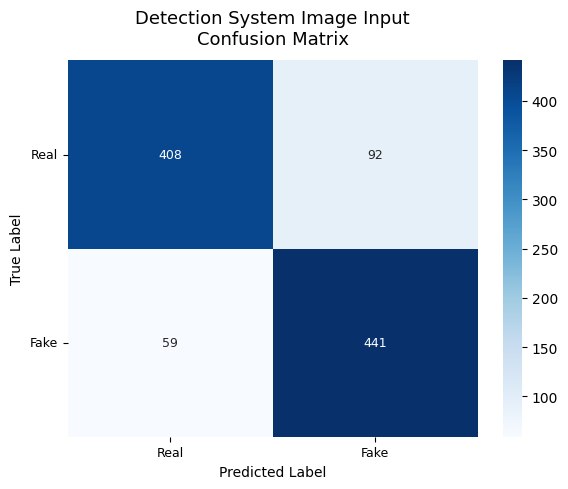

In [ ]:
# =============================================================================
# IMAGE INPUT TEST
# =============================================================================

IMAGE_RESULTS_DF, IMAGE_METRICS = eval_detection_system(
    DETECTION_SYSTEM,
    IMAGE_INPUTS,
    eval_name="detection_system_image_input",
)

print_metrics(
    "DETECTION SYSTEM - IMAGE INPUT",
    IMAGE_METRICS,
    df=IMAGE_RESULTS_DF,
)

IMAGE_SAVE_PATHS = save_eval(
    "Detection System Image Input",
    IMAGE_RESULTS_DF,
    IMAGE_METRICS,
    show_cm=True,
)

Evaluating detection_system_video_input:   0%|          | 0/1500 [00:00<?, ?it/s]


DETECTION SYSTEM - VIDEO INPUT

OVERALL METRICS
Total samples       : 1,500
Processed samples   : 1,500
Failed samples      : 0
Success rate        : 1.0000
End-to-end accuracy : 0.9593
Precision           : 0.9593
Recall              : 0.9593
F1-score            : 0.9593

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.96      0.96      0.96       750
        Fake       0.96      0.96      0.96       750

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500


ROUTING REPORT
Routing total       : 1,500
Correct route       : 1,500
Wrong route         : 0
Routing accuracy    : 1.0000

CONFUSION MATRIX


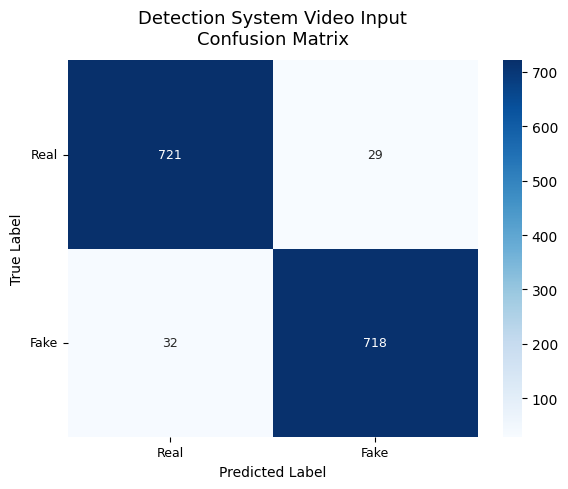

In [ ]:
# =============================================================================
# VIDEO INPUT TEST
# =============================================================================

VIDEO_RESULTS_DF, VIDEO_METRICS = eval_detection_system(
    DETECTION_SYSTEM,
    VIDEO_INPUTS,
    eval_name="detection_system_video_input",
)

print_metrics(
    "DETECTION SYSTEM - VIDEO INPUT",
    VIDEO_METRICS,
    df=VIDEO_RESULTS_DF,
)

VIDEO_SAVE_PATHS = save_eval(
    "Detection System Video Input",
    VIDEO_RESULTS_DF,
    VIDEO_METRICS,
    show_cm=True,
)

Evaluating detection_system_mixed_input:   0%|          | 0/1500 [00:00<?, ?it/s]


DETECTION SYSTEM - MIXED INPUT

OVERALL METRICS
Total samples       : 1,500
Processed samples   : 1,500
Failed samples      : 0
Success rate        : 1.0000
End-to-end accuracy : 0.9073
Precision           : 0.9077
Recall              : 0.9073
F1-score            : 0.9073

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.92      0.89      0.91       750
        Fake       0.90      0.92      0.91       750

    accuracy                           0.91      1500
   macro avg       0.91      0.91      0.91      1500
weighted avg       0.91      0.91      0.91      1500


ROUTING REPORT
Routing total       : 1,500
Correct route       : 1,500
Wrong route         : 0
Routing accuracy    : 1.0000

CONFUSION MATRIX


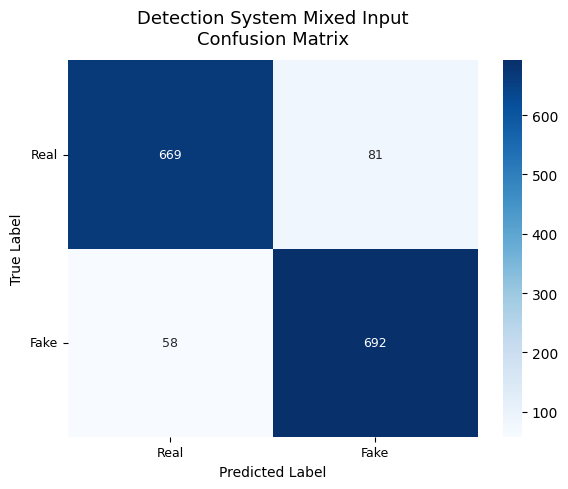

In [ ]:
# =============================================================================
# MIXED INPUT TEST
# =============================================================================

MIXED_RESULTS_DF, MIXED_METRICS = eval_detection_system(
    DETECTION_SYSTEM,
    MIXED_INPUTS,
    eval_name="detection_system_mixed_input",
)

print_metrics(
    "DETECTION SYSTEM - MIXED INPUT",
    MIXED_METRICS,
    df=MIXED_RESULTS_DF,
)

MIXED_SAVE_PATHS = save_eval(
    "Detection System Mixed Input",
    MIXED_RESULTS_DF,
    MIXED_METRICS,
    show_cm=True,
)

In [ ]:
# =============================================================================
# LOAD BASELINE METRICS FOR FINAL COMPARISON
# =============================================================================

def read_any(paths, label):
    """Read the first available JSON metric file."""
    for path in paths:
        data = read_json(path)
        if data is not None:
            print(f"✓ {label}: {path}")
            return data
    print(f"⚠ {label}: no metric file found")
    for path in paths:
        print(f"  checked: {path}")
    return None

_, _, image_report_dir, _ = make_dirs(CONF.IMAGE_EXP)
_, _, video_report_dir, _ = make_dirs(CONF.VIDEO_EXP)

IMAGE_TEST_JSON = read_any([
    os.path.join(image_report_dir, f"{CONF.IMAGE_EXP}_binary_metrics.json"),
    os.path.join(image_report_dir, "image_1e-3_binary_metrics.json"),
], "Image model on image input")

IMAGE_ON_VIDEO_JSON = read_any([
    os.path.join(image_report_dir, f"{CONF.IMAGE_EXP}_cross_metrics.json"),
    os.path.join(image_report_dir, "image_1e-3_cross_metrics.json"),
], "Image model on video input")

IMAGE_MIXED_JSON = read_any([
    os.path.join(image_report_dir, f"{CONF.IMAGE_EXP}_mixed_metrics.json"),
    os.path.join(image_report_dir, "image_1e-3_mixed_metrics.json"),
], "Image model on mixed input")

VIDEO_TEST_JSON = read_any([
    os.path.join(video_report_dir, f"{CONF.VIDEO_EXP}_test_metrics.json"),
    os.path.join(video_report_dir, "video_test_metrics.json"),
], "Video model on video input")

VIDEO_ON_IMAGE_JSON = read_any([
    os.path.join(video_report_dir, f"{CONF.VIDEO_EXP}_cross_metrics.json"),
    os.path.join(video_report_dir, "video_model_on_image_test_set_metrics.json"),
], "Video model on image input")

VIDEO_MIXED_JSON = read_any([
    os.path.join(video_report_dir, f"{CONF.VIDEO_EXP}_mixed_metrics.json"),
    os.path.join(video_report_dir, "video_model_mixed_test_metrics.json"),
], "Video model on mixed input")

✓ Image model on image input: /content/drive/MyDrive/skripsi/experiments/image_1e-3/reports/image_1e-3_binary_metrics.json
✓ Image model on video input: /content/drive/MyDrive/skripsi/experiments/image_1e-3/reports/image_1e-3_cross_metrics.json
✓ Image model on mixed input: /content/drive/MyDrive/skripsi/experiments/image_1e-3/reports/image_1e-3_mixed_metrics.json
✓ Video model on video input: /content/drive/MyDrive/skripsi/experiments/video_1e-4/reports/video_1e-4_test_metrics.json
✓ Video model on image input: /content/drive/MyDrive/skripsi/experiments/video_1e-4/reports/video_1e-4_cross_metrics.json
✓ Video model on mixed input: /content/drive/MyDrive/skripsi/experiments/video_1e-4/reports/video_1e-4_mixed_metrics.json


In [ ]:
# =============================================================================
# FINAL TABLES
# =============================================================================

def m_metric(metrics, keys):
    """Read metric value from several possible keys."""
    return get_val(metrics, keys, np.nan)

def m_score(metrics, keys):
    """Read score metric as 0-1 ratio."""
    return safe_ratio(m_metric(metrics, keys))

def m_accuracy(metrics):
    return m_score(metrics, ["end_to_end_accuracy", "accuracy", "test_accuracy"])

def m_precision(metrics):
    return m_score(metrics, ["precision", "precision_weighted", "weighted_precision"])

def m_recall(metrics):
    return m_score(metrics, ["recall", "recall_weighted", "weighted_recall"])

def m_f1(metrics):
    return m_score(metrics, ["f1", "f1_score", "f1_weighted", "weighted_f1"])

def quality_metrics(metrics):
    """Prediction-quality metrics for final comparison."""
    return {
        "Accuracy": m_accuracy(metrics),
        "Precision": m_precision(metrics),
        "Recall": m_recall(metrics),
        "F1-Score": m_f1(metrics),
    }

def row_input(model_name, input_type, metrics):
    """Row for per-input quality comparison."""
    row = {
        "Model": model_name,
        "Input Type": input_type,
        "Num Samples": get_val(metrics, ["num_samples", "processed_samples"], np.nan),
        "Success Rate": m_success(metrics),
    }
    row.update(quality_metrics(metrics))
    row.update({"Routing Accuracy": m_route_acc(metrics)})
    return row

def row_system(system_name, routing, metrics):
    """Row for mixed-input system comparison."""
    row = {
        "System": system_name,
        "Input": "Mixed image + video",
        "Routing": routing,
        "Num Samples": get_val(metrics, ["num_samples", "processed_samples"], np.nan),
        "Success Rate": m_success(metrics),
    }
    row.update(quality_metrics(metrics))
    row.update({"Routing Accuracy": m_route_acc(metrics)})
    return row

comparison_rows = [
    ("Image Model", "Image", IMAGE_TEST_JSON),
    ("Image Model", "Video", IMAGE_ON_VIDEO_JSON),
    ("Image Model", "Mixed Input", IMAGE_MIXED_JSON),
    ("Video Model", "Image", VIDEO_ON_IMAGE_JSON),
    ("Video Model", "Video", VIDEO_TEST_JSON),
    ("Video Model", "Mixed Input", VIDEO_MIXED_JSON),
    ("Detection System", "Image", IMAGE_METRICS),
    ("Detection System", "Video", VIDEO_METRICS),
    ("Detection System", "Mixed Input", MIXED_METRICS),
]

BY_INPUT_DF = pd.DataFrame([row_input(model, input_type, metrics) for model, input_type, metrics in comparison_rows])

SYSTEM_DF = pd.DataFrame([
    row_system("Image-only baseline", "None", IMAGE_MIXED_JSON),
    row_system("Video-only baseline", "None", VIDEO_MIXED_JSON),
    row_system("Proposed detection system", "Automatic", MIXED_METRICS),
])

MODEL_ORDER = ["Image Model", "Video Model", "Detection System"]
INPUT_ORDER = ["Image", "Video", "Mixed Input"]
INPUT_LABELS = {
    "Image": "Input Gambar",
    "Video": "Input Video",
    "Mixed Input": "Mixed Input",
}

ACCURACY_DF = (
    BY_INPUT_DF
    .pivot(index="Model", columns="Input Type", values="Accuracy")
    .reindex(index=MODEL_ORDER, columns=INPUT_ORDER)
    .rename(columns=INPUT_LABELS)
    .reset_index()
)

ACCURACY_TABLE = ACCURACY_DF.copy()
for col in ["Input Gambar", "Input Video", "Mixed Input"]:
    ACCURACY_TABLE[col] = pd.to_numeric(ACCURACY_TABLE[col], errors="coerce").round(4)

MAIN_METRICS_TABLE = BY_INPUT_DF.copy()
quality_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "Success Rate", "Routing Accuracy"]
for col in quality_cols:
    if col in MAIN_METRICS_TABLE.columns:
        MAIN_METRICS_TABLE[col] = pd.to_numeric(MAIN_METRICS_TABLE[col], errors="coerce").round(4)

print("=" * 80)
print("ACCURACY COMPARISON")
print("=" * 80)
display(ACCURACY_TABLE)

print("=" * 80)
print("MAIN QUALITY METRICS")
print("=" * 80)
display(MAIN_METRICS_TABLE)

accuracy_csv = os.path.join(REPORT_DIR, "accuracy_comparison.csv")
by_input_csv = os.path.join(REPORT_DIR, "comparison_quality_metrics_by_input_type.csv")
system_csv = os.path.join(REPORT_DIR, "final_mixed_system_metrics.csv")

ACCURACY_DF.to_csv(accuracy_csv, index=False)
BY_INPUT_DF.to_csv(by_input_csv, index=False)
SYSTEM_DF.to_csv(system_csv, index=False)

print("Saved:")
print(f"  {accuracy_csv}")
print(f"  {by_input_csv}")
print(f"  {system_csv}")

ACCURACY COMPARISON


Input Type,Model,Input Gambar,Input Video,Mixed Input
0,Image Model,0.846,0.4447,0.6427
1,Video Model,0.515,0.9300,0.7247
2,Dual-Path,0.846,0.9300,0.8907


Saved:
  /content/drive/MyDrive/skripsi/experiments/dual_path/reports/accuracy_comparison.csv
  /content/drive/MyDrive/skripsi/experiments/dual_path/reports/comparison_metrics_by_input_type.csv
  /content/drive/MyDrive/skripsi/experiments/dual_path/reports/final_mixed_system_metrics.csv


In [ ]:
# =============================================================================
# VISUALIZE FINAL COMPARISON
# =============================================================================

os.makedirs(VIS_DIR, exist_ok=True)


def metric_pivot(df, metric_col):
    plot_df = (
        df
        .pivot(index="Model", columns="Input Type", values=metric_col)
        .reindex(index=MODEL_ORDER, columns=INPUT_ORDER)
        .rename(columns=INPUT_LABELS)
    )

    for col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    return plot_df


def plot_metric(metric_col, title, ylabel, filename, ylim=None):
    plot_df = metric_pivot(BY_INPUT_DF, metric_col)
    plot_df = plot_df.dropna(axis=1, how="all")

    if plot_df.empty or len(plot_df.columns) == 0:
        print(f"⚠ Skipped {title}: no available metric values")
        return None

    ax = plot_df.plot(kind="bar", figsize=(9.5, 5.5))
    ax.set_title(title, fontsize=15, fontweight="normal", pad=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_xticklabels(plot_df.index, rotation=0)
    ax.grid(axis="y", alpha=0.3)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.legend(title="Input Type", loc="best")
    plt.tight_layout()

    save_path = os.path.join(VIS_DIR, filename)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return save_path


metric_specs = [
    ("Accuracy", "Accuracy Comparison", "Score", "comparison_accuracy.png", (0, 1.05)),
    ("Precision", "Precision Comparison", "Score", "comparison_precision.png", (0, 1.05)),
    ("Recall", "Recall Comparison", "Score", "comparison_recall.png", (0, 1.05)),
    ("F1-Score", "F1-Score Comparison", "Score", "comparison_f1_score.png", (0, 1.05)),
]

saved_paths = []
for metric_col, title, ylabel, filename, ylim in metric_specs:
    path = plot_metric(metric_col, title, ylabel, filename, ylim)
    if path is not None:
        saved_paths.append(path)

print("✓ Visualizations saved:")
for path in saved_paths:
    print(f"  {path}")

Upload image or video


Saving Download (2).mp4 to Download (2).mp4
PREDICTION RESULTS
Input Type       : Video
Route Selected   : video_path
Predicted Class  : Fake
Confidence       : 82.36%
Subtype          : T2V
Routing overhead : 0.02 ms
Total Time       : 8,426.21 ms

Class Probabilities:
  Real                 : 17.64%
  Fake                 : 82.36%

Subtype: T2V

Subtype Probabilities:
  Change_of_style     : 0.24%
  Extrapolation       : 3.39%
  Faceswap            : 0.02%
  Inpainting          : 0.21%
  Interpolation       : 0.50%
  Outpainting         : 0.17%
  T2V                 : 90.56%
  TI2V                : 4.91%


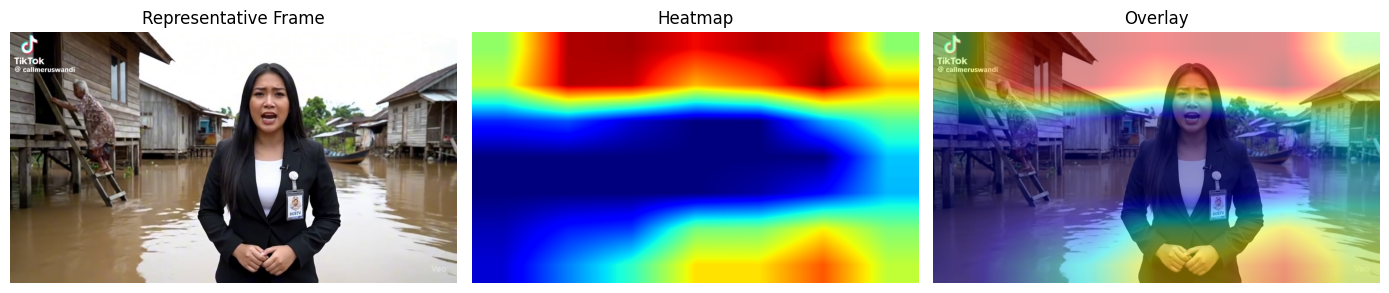

In [ ]:
# =============================================================================
# FINAL INFERENCE WITH HEATMAP
# =============================================================================

SHOW_HEATMAP = True
USE_UPLOAD = True
MAX_FALLBACK_EXAMPLES = 4
UPLOAD_DIR = "/content/manual_detection_inputs"
os.makedirs(UPLOAD_DIR, exist_ok=True)


def fmt_pct(x):
    if x is None or pd.isna(x):
        return "-"
    return f"{float(x) * 100:.2f}%"



def infer_true_label(file_path, kind):
    """Infer true label from dataset folder name when possible."""
    text = str(file_path).replace("\\", "/").lower()
    if kind == "image":
        if "/real/" in text:
            return 0
        if "/full_synthetic/" in text or "/tampered/" in text or "/fake/" in text:
            return 1
    if kind == "video":
        if "/real/" in text:
            return 0
        if "/fake/" in text:
            return 1
    return None


def norm_map(x):
    """Normalize heatmap to 0-1."""
    x = np.asarray(x, dtype=np.float32)
    x = x - np.nanmin(x)
    return x / (np.nanmax(x) + 1e-8)


def overlay_map(rgb, heatmap, alpha=0.45):
    """Overlay heatmap on an RGB image/frame."""
    rgb = np.asarray(rgb).astype(np.uint8)
    if rgb.ndim == 2:
        rgb = np.stack([rgb] * 3, axis=-1)

    heatmap = norm_map(heatmap)
    if heatmap.shape[:2] != rgb.shape[:2]:
        heatmap = cv2.resize(heatmap, (rgb.shape[1], rgb.shape[0]))

    heat_u8 = np.uint8(255 * heatmap)
    heat_color = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(rgb, 1 - alpha, heat_color, alpha, 0)


def image_cam_layer(model):
    """Find the last convolution layer for image Grad-CAM."""
    if hasattr(model, "backbone"):
        if hasattr(model.backbone, "conv_head"):
            return model.backbone.conv_head
        convs = [m for m in model.backbone.modules() if isinstance(m, nn.Conv2d)]
        if convs:
            return convs[-1]

    convs = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    return convs[-1] if convs else None


def make_image_cam(file_path, target_class=None):
    """Create image heatmap using Grad-CAM or fallback saliency."""
    image_model.eval()
    img = Image.open(file_path).convert("RGB")
    original = np.array(img)
    x = IMAGE_TF(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = image_model(x)
        probs = F.softmax(logits, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())

    if target_class is None or pd.isna(target_class):
        target_class = pred_class
    target_class = int(target_class)

    layer = image_cam_layer(image_model)
    if GradCAM is not None and ClassifierOutputTarget is not None and layer is not None:
        try:
            cam = GradCAM(model=image_model, target_layers=[layer])
            heatmap = cam(input_tensor=x, targets=[ClassifierOutputTarget(target_class)])[0]
            heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
            return original, heatmap, overlay_map(original, heatmap)
        except Exception as e:
            print(f"Grad-CAM failed, using fallback saliency: {e}")

    # Fallback saliency
    x_grad = x.clone().detach().requires_grad_(True)
    image_model.zero_grad(set_to_none=True)
    logits = image_model(x_grad)
    score = logits[0, target_class]
    score.backward()
    saliency = x_grad.grad.detach().abs().max(dim=1)[0][0].cpu().numpy()
    heatmap = cv2.resize(norm_map(saliency), (original.shape[1], original.shape[0]))
    return original, heatmap, overlay_map(original, heatmap)



def video_cam_layer(model):
    """Find the last convolution layer inside the video backbone."""
    if hasattr(model, "features"):
        conv_layers = [module for module in model.features.modules() if isinstance(module, nn.Conv2d)]
        if len(conv_layers) > 0:
            return conv_layers[-1]
        try:
            return model.features[-1]
        except Exception:
            pass

    conv_layers = [module for module in model.modules() if isinstance(module, nn.Conv2d)]
    return conv_layers[-1] if len(conv_layers) > 0 else None

def video_gradcam(normed_tensor, target_class):
    """Frame-level Grad-CAM for the selected video backbone."""
    video_model.eval()
    activations, gradients = {}, {}
    layer = video_cam_layer(video_model)

    if layer is None:
        print("Video Grad-CAM skipped: no convolution layer was found.")
        return None

    def save_act(module, inp, out):
        activations["value"] = out.detach()

    def save_grad(module, grad_in, grad_out):
        gradients["value"] = grad_out[0].detach()

    h1 = layer.register_forward_hook(save_act)
    h2 = layer.register_full_backward_hook(save_grad)

    try:
        video_model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            binary_logits, _ = video_model(normed_tensor)
            score = binary_logits[0, int(target_class)]
            score.backward()

        if "value" not in activations or "value" not in gradients:
            return None

        act = activations["value"]
        grad = gradients["value"]
        weights = grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * act).sum(dim=1))

        t = cam.shape[0]
        cam_min = cam.view(t, -1).min(dim=1)[0].view(t, 1, 1)
        cam_max = cam.view(t, -1).max(dim=1)[0].view(t, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        _, _, _, h, w = normed_tensor.shape
        cam = F.interpolate(cam.unsqueeze(1), size=(h, w), mode="bilinear", align_corners=False).squeeze(1)
        return cam.detach().cpu().numpy()

    except Exception as e:
        print(f"Video Grad-CAM failed: {e}")
        return None

    finally:
        h1.remove()
        h2.remove()


def make_video_cam(file_path, target_class=None):
    """Create heatmap for one representative video frame."""
    frames = read_frames(file_path, CONF.MAX_VIDEO_DURATION, CONF.NUM_FRAMES)
    if frames is None or len(frames) == 0:
        return None, None, None

    tensor = frames_to_tensor(frames, size=CONF.FRAME_SIZE)
    normed = VideoNorm()(tensor).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        binary_logits, _ = video_model(normed)
        probs = F.softmax(binary_logits, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())

    if target_class is None or pd.isna(target_class):
        target_class = pred_class
    target_class = int(target_class)

    cams = video_gradcam(normed, target_class)
    if cams is None:
        return None, None, None

    if target_class == 1:
        scores = cams.reshape(cams.shape[0], -1).mean(axis=1)
        idx = int(np.argmax(scores))
    else:
        idx = len(frames) // 2

    frame = np.asarray(frames[idx]).astype(np.uint8)
    heatmap = cams[idx]

    if heatmap.shape[:2] != frame.shape[:2]:
        heatmap = cv2.resize(
            heatmap,
            (frame.shape[1], frame.shape[0]),
            interpolation=cv2.INTER_LINEAR,
        )

    return frame, heatmap, overlay_map(frame, heatmap)

def show_triplet(a, b, c, titles):
    """Display original, heatmap, and overlay."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
    images = [a, b, c]
    for ax, img, title in zip(axes, images, titles):
        if title == "Heatmap":
            ax.imshow(img, cmap="jet")
        else:
            ax.imshow(img)
        ax.set_title(title, fontweight="normal")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_heatmap(row):
    """Show forensic visualization for the selected path."""
    if not SHOW_HEATMAP:
        return

    kind = str(row.get("actual_media_type", "")).lower()
    file_path = row.get("file_path")

    if kind == "image":
        native_id = row.get("native_label_id", None)
        original, heatmap, overlay = make_image_cam(file_path, target_class=native_id)
        show_triplet(original, heatmap, overlay, ["Original", "Heatmap", "Overlay"])

    elif kind == "video":
        binary_id = row.get("binary_label_id", None)
        frame, heatmap, overlay = make_video_cam(file_path, target_class=binary_id)
        if frame is None:
            print("Heatmap skipped: video heatmap failed.")
            return
        show_triplet(frame, heatmap, overlay, ["Representative Frame", "Heatmap", "Overlay"])


def upload_inputs(upload_dir):
    """Upload image/video files in Colab."""
    try:
        from google.colab import files
    except Exception:
        print("Upload is only available in Google Colab.")
        return []

    print("Upload image or video")
    uploaded = files.upload()
    paths = []

    for name, content in uploaded.items():
        out_path = os.path.join(upload_dir, name)
        with open(out_path, "wb") as f:
            f.write(content)
        paths.append(out_path)

    return paths


def pick_examples(df):
    """Pick fallback examples from evaluated mixed input."""
    targets = [("image", 0), ("image", 1), ("video", 0), ("video", 1)]
    paths = []
    for kind, label in targets:
        rows = df[
            (df["actual_media_type"] == kind) &
            (df["true_label"] == label) &
            (df["pipeline_success"] == True)
        ]
        if len(rows):
            paths.append(rows.iloc[0]["file_path"])
    return paths[:MAX_FALLBACK_EXAMPLES]


def predict_input(file_path):
    """Run final detection system inference on one file."""
    kind = media_type(file_path)
    true_label = infer_true_label(file_path, kind)
    result = DETECTION_SYSTEM.run(
        file_path=file_path,
        actual_media_type=kind if kind != "unknown" else None,
        true_label=true_label,
    )
    return pd.Series(result)


def print_probs(row):
    """Print class probabilities based on selected path."""
    probs = row.get("path_specific_probabilities", {})
    if not isinstance(probs, dict):
        probs = {}

    if row.get("actual_media_type") == "image":
        print("\nClass Probabilities:")
        for label in IMAGE_NAMES:
            print(f"  {label:<20}: {fmt_pct(probs.get(label))}")

    else:
        print("\nClass Probabilities:")
        print(f"  Real                 : {fmt_pct(row.get('prob_real'))}")
        print(f"  Fake                 : {fmt_pct(row.get('prob_fake'))}")

    if row.get("actual_media_type") == "video" and row.get("path_specific_subtype"):
        print(f"\nSubtype: {row.get('path_specific_subtype')}")
        subtype_probs = probs.get("subtype_probabilities")
        if subtype_probs is None and all(label in probs for label in SUBTYPE_NAMES):
            subtype_probs = probs
        if isinstance(subtype_probs, dict):
            print("\nSubtype Probabilities:")
            for label in SUBTYPE_NAMES:
                if label in subtype_probs:
                    print(f"  {label:<20}: {fmt_pct(subtype_probs[label])}")

def show_result(row):
    """Print final detection system prediction."""
    kind = str(row.get("actual_media_type", "unknown")).lower()

    # Image uses native 3-class prediction.
    if kind == "image":
        predicted_class = row.get("native_label_name", row.get("final_label_name", "-"))

        native_confidence = row.get("native_confidence", np.nan)
        if native_confidence is not None and not pd.isna(native_confidence):
            confidence = native_confidence
        else:
            confidence = row.get("confidence")

    # Video uses final binary prediction.
    else:
        predicted_class = row.get("final_label_name", "-")
        confidence = row.get("confidence")

    print("=" * 80)
    print("PREDICTION RESULTS")
    print("=" * 80)
    print(f"Input Type       : {kind.title()}")
    print(f"Route Selected   : {row.get('route_selected', '-')}")
    print(f"Predicted Class  : {predicted_class}")
    print(f"Confidence       : {fmt_pct(confidence)}")

    if kind == "video" and row.get("path_specific_subtype"):
        print(f"Subtype          : {row.get('path_specific_subtype')}")

    true_label = row.get("true_label", None)
    if true_label is not None and not pd.isna(true_label):
        print(f"True Class       : {BINARY_ID_TO_NAME[int(true_label)]}")
        print(f"Correct          : {bool(row.get('final_correct'))}")

    print_probs(row)
    show_heatmap(row)

# Run final inference
if USE_UPLOAD:
    input_paths = upload_inputs(UPLOAD_DIR)
else:
    input_paths = pick_examples(MIXED_RESULTS_DF)

if len(input_paths) == 0:
    print("No input was provided.")
else:
    for input_path in input_paths:
        row = predict_input(input_path)
        show_result(row)